In [1]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 14.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 22.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 43.5MB/s]


In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
data = pd.read_csv('./train.csv')

**Первая часть. Исследование**

In [4]:
data.sample(7)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1083,10,20.00,185.4,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,0
1134,55,58.60,3068.6,Male,0,Yes,No,Yes,No,DSL,Yes,Yes,Yes,No,No,No,Two year,No,Electronic check,0
1335,27,20.05,552.9,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),0
2485,1,20.15,20.15,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),0
2713,1,74.35,74.35,Male,0,No,No,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,1
4783,17,64.80,1175.6,Male,0,Yes,No,Yes,No,DSL,Yes,Yes,No,No,No,Yes,One year,No,Mailed check,0
290,71,100.45,7159.7,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,No,Yes,Two year,No,Electronic check,0


In [10]:
# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [6]:
data['TotalSpent'] = data['TotalSpent'].replace(' ', 0)
data['TotalSpent'] = data['TotalSpent'].astype(float)

In [7]:
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   float64
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

*Незаполненных значений нет.*

##**Анализ данных**

In [9]:
plt.style.use('seaborn-v0_8-pastel')

Целевая переменная

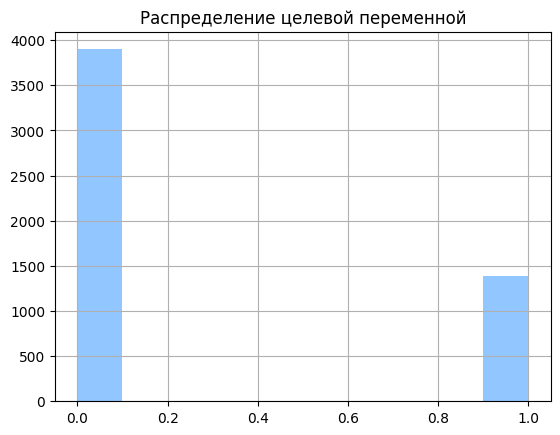

In [10]:
data[target_col].hist()
plt.title('Распределение целевой переменной')
plt.show()

Можем считать переменную сбалансированной

Анализируем численные признаки

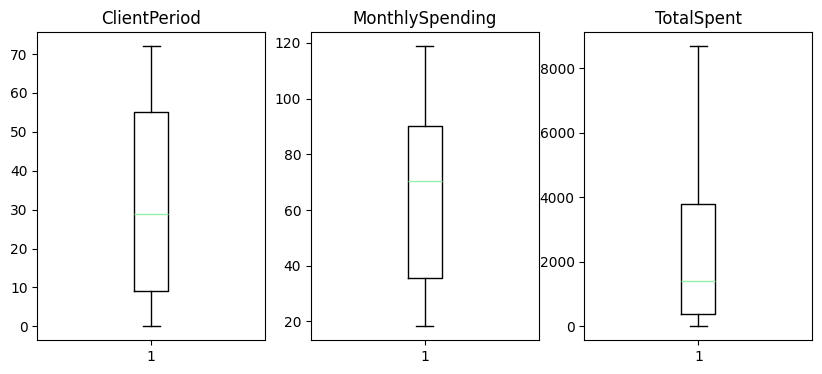

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

ax1.boxplot(data['ClientPeriod'])
ax2.boxplot(data['MonthlySpending'])
ax3.boxplot(data['TotalSpent'])

ax1.set_title(num_cols[0])
ax2.set_title(num_cols[1])
ax3.set_title(num_cols[2])

plt.show()

*Выбросов нет*

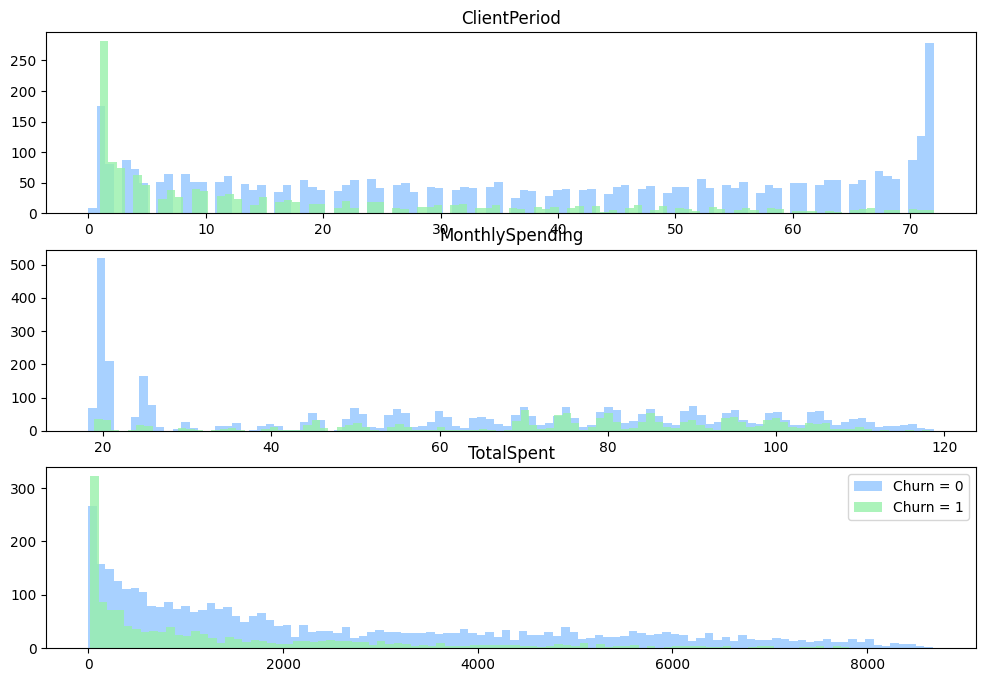

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8))

ax1.hist(data[data['Churn'] == 0]['ClientPeriod'], bins=100, alpha=0.8, label='Churn = 0')
ax1.hist(data[data['Churn'] == 1]['ClientPeriod'], bins=100, alpha=0.8, label='Churn = 1')
ax2.hist(data[data['Churn'] == 0]['MonthlySpending'], bins=100, alpha=0.8, label='Churn = 0')
ax2.hist(data[data['Churn'] == 1]['MonthlySpending'], bins=100, alpha=0.8, label='Churn = 1')
ax3.hist(data[data['Churn'] == 0]['TotalSpent'], bins=100, alpha=0.8, label='Churn = 0')
ax3.hist(data[data['Churn'] == 1]['TotalSpent'], bins=100, alpha=0.8, label='Churn = 1')

ax1.set_title(num_cols[0])
ax2.set_title(num_cols[1])
ax3.set_title(num_cols[2])

plt.legend()
plt.show()

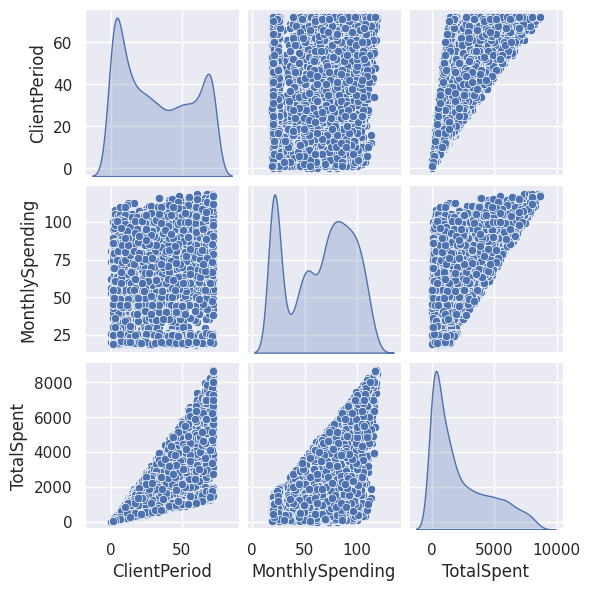

In [13]:
sns.set()
sns.pairplot(data[num_cols], height=2 ,kind ='scatter', diag_kind='kde') # взаимные графики на куче признаков
plt.show()

Категориальные признаки

In [14]:
def show_plt(col):
  "Вывод pie chart для одного категориального признака"
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,8))

  ax1.pie(data[data['Churn'] == 0][col].value_counts(), autopct='%1.1f%%', textprops={'fontsize': 10})
  ax2.pie(data[data['Churn'] == 1][col].value_counts(), autopct='%1.1f%%', textprops={'fontsize': 10})

  ax1.set_title('Churn = 0', fontsize=10)
  ax2.set_title('Churn = 1', fontsize=10)

  ax2.legend(data[col].value_counts().index, fontsize=9, bbox_to_anchor=(0.5, -0.04), ncol=2)
  plt.text(-1.5, 1.2, col, horizontalalignment='center', verticalalignment='center', fontsize=10)
  plt.show()

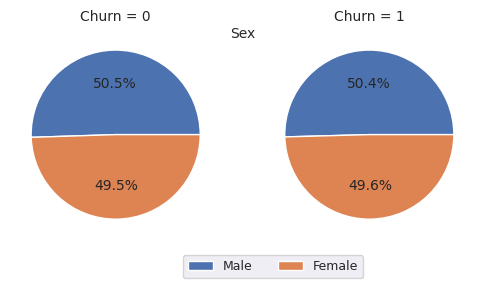

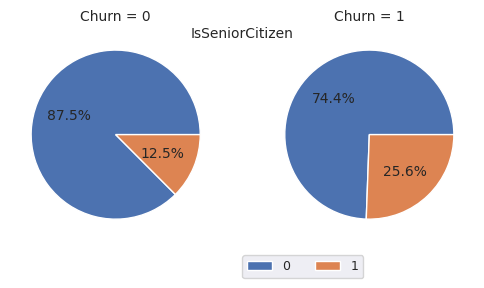

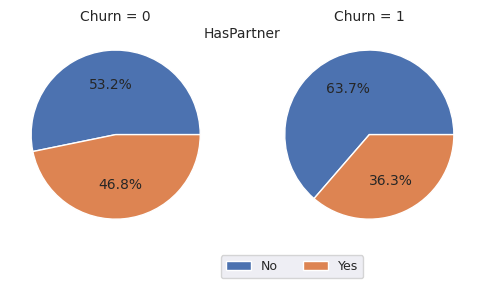

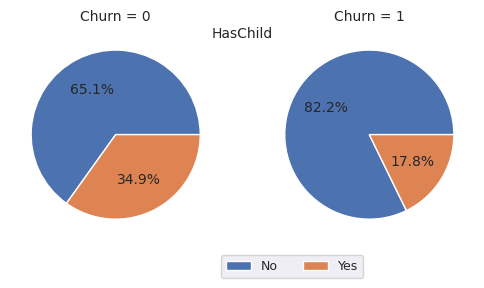

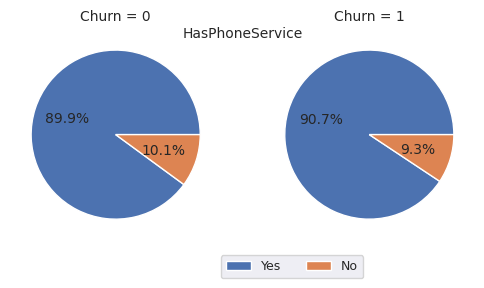

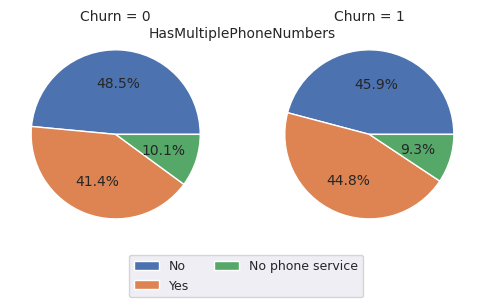

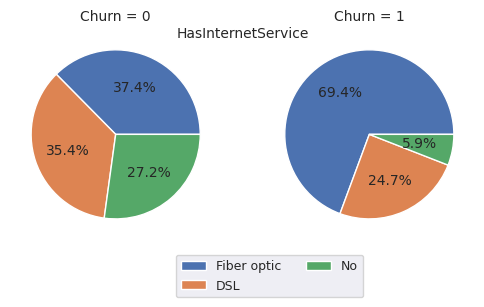

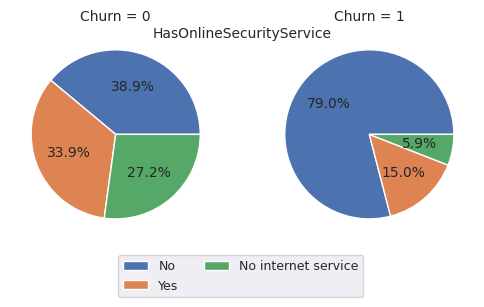

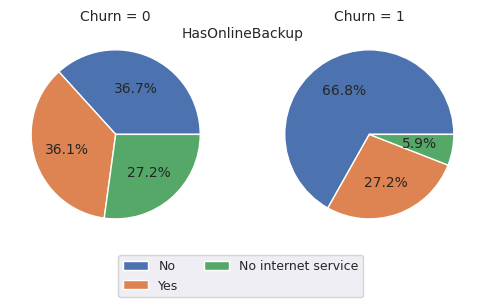

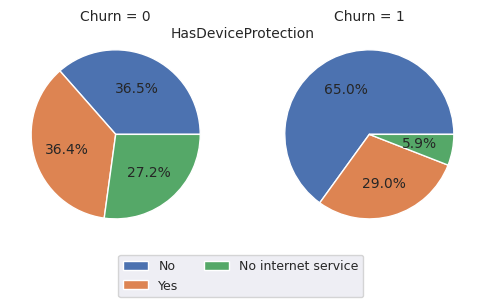

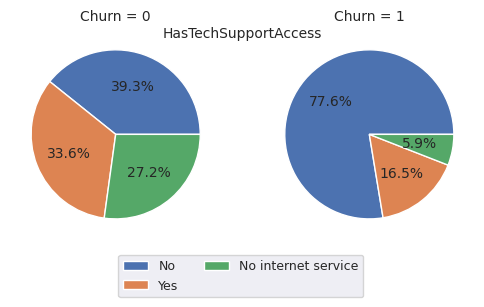

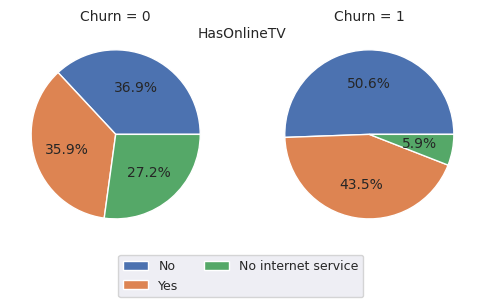

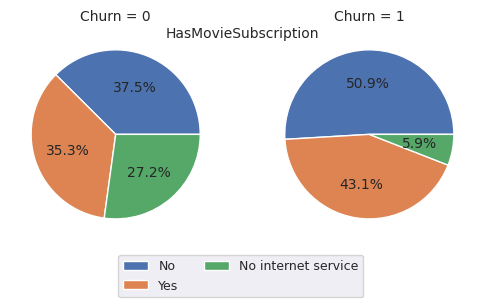

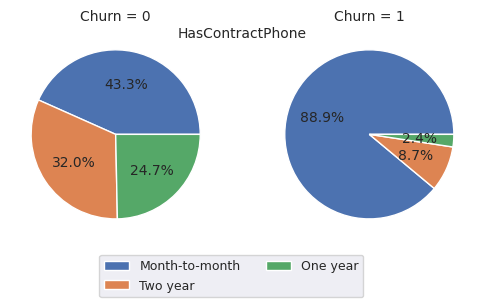

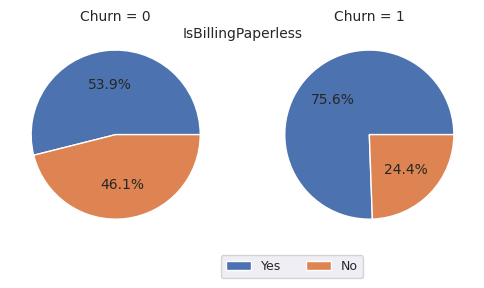

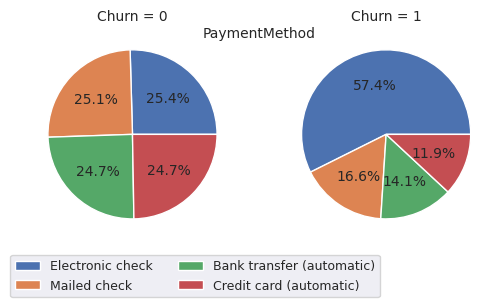

In [15]:
for col in cat_cols:
  show_plt(col)

По результатам предварительного анализа делаем вывод о возможности удаления некоторых столбцов.

In [16]:
del_col = ['HasOnlineBackup', 'HasDeviceProtection', 'HasMovieSubscription']
cat_cols = [i for i in cat_cols if i not in del_col]
data = data.drop(del_col, axis=1)

##**Применение линейных моделей**

In [6]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

Применим One hot encoder для категориальных данных

In [18]:
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the categorical data
one_hot_encoded = encoder.fit_transform(data[cat_cols])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cat_cols), index=data.index
                          )

In [19]:
# Concatenate the one-hot encoded dataframe with the original dataframe
df = pd.concat([data, one_hot_df], axis=1)

# Drop the original categorical columns
df = df.drop(cat_cols, axis=1)

# Display the resulting dataframe
df

,ClientPeriod,MonthlySpending,TotalSpent,Churn,Sex_Female,Sex_Male,IsSeniorCitizen_0,IsSeniorCitizen_1,HasPartner_No,HasPartner_Yes,...,HasOnlineTV_Yes,HasContractPhone_Month-to-month,HasContractPhone_One year,HasContractPhone_Two year,IsBillingPaperless_No,IsBillingPaperless_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,55,19.50,1026.35,0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,72,25.85,1872.20,0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,75.90,75.90,1,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,32,79.30,2570.00,0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,115.25,6758.45,0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5278,50,44.45,2188.45,0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5279,1,55.05,55.05,0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5280,29,76.00,2215.25,0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


Получаем матрицы X, y. Разделяем на обучающую и тестовую. Нормируем.

In [20]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values,
                                                    train_size=0.8,
                                                    random_state=42)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##**LogisticRegression**

In [23]:
param_c = [100, 10, 1, 0.1, 0.01, 0.001]

model = LogisticRegressionCV(Cs=param_c, n_jobs=-1, scoring='roc_auc', refit=True)

model.fit(X_train_scaled, y_train)

LogisticRegressionCV(Cs=[100, 10, 1, 0.1, 0.01, 0.001], n_jobs=-1,
                     scoring='roc_auc')

In [24]:
y_pred = model.predict_proba(X_test_scaled)[:, 1]
roc_auc_score(y_test, y_pred)

np.float64(0.8285895032369481)

Полученный результат roc_auc_score =
0.8285895032369481

##**Градиентный бустинг**

In [1]:
from catboost import CatBoostClassifier

In [7]:
dt = pd.read_csv('./train.csv')

dt['TotalSpent'] = dt['TotalSpent'].replace(' ', 0)
dt['TotalSpent'] = dt['TotalSpent'].astype(float)

del_col = ['HasOnlineBackup', 'HasDeviceProtection', 'HasMovieSubscription']
cat_cols = [i for i in cat_cols if i not in del_col]
dt = dt.drop(del_col, axis=1)
X = dt.drop(['Churn'], axis=1)
y = dt['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
boosting_model = CatBoostClassifier()

boosting_model.fit(X_train, y_train, cat_features=cat_cols)

y_train_predicted = boosting_model.predict_proba(X_train)[:, 1]
y_test_predicted = boosting_model.predict_proba(X_test)[:, 1]

Learning rate set to 0.019062
0:	learn: 0.6799661	total: 61ms	remaining: 1m
1:	learn: 0.6682027	total: 71ms	remaining: 35.4s
2:	learn: 0.6565064	total: 81.4ms	remaining: 27s
3:	learn: 0.6454337	total: 91.3ms	remaining: 22.7s
4:	learn: 0.6346876	total: 101ms	remaining: 20.2s
5:	learn: 0.6240494	total: 110ms	remaining: 18.3s
6:	learn: 0.6146114	total: 119ms	remaining: 16.9s
7:	learn: 0.6066093	total: 125ms	remaining: 15.5s
8:	learn: 0.5977178	total: 135ms	remaining: 14.8s
9:	learn: 0.5894816	total: 144ms	remaining: 14.3s
10:	learn: 0.5825270	total: 151ms	remaining: 13.6s
11:	learn: 0.5752725	total: 160ms	remaining: 13.2s
12:	learn: 0.5687391	total: 169ms	remaining: 12.9s
13:	learn: 0.5620345	total: 180ms	remaining: 12.6s
14:	learn: 0.5558983	total: 189ms	remaining: 12.4s
15:	learn: 0.5500329	total: 198ms	remaining: 12.2s
16:	learn: 0.5456008	total: 205ms	remaining: 11.9s
17:	learn: 0.5395758	total: 214ms	remaining: 11.7s
18:	learn: 0.5340498	total: 224ms	remaining: 11.6s
19:	learn: 0.528

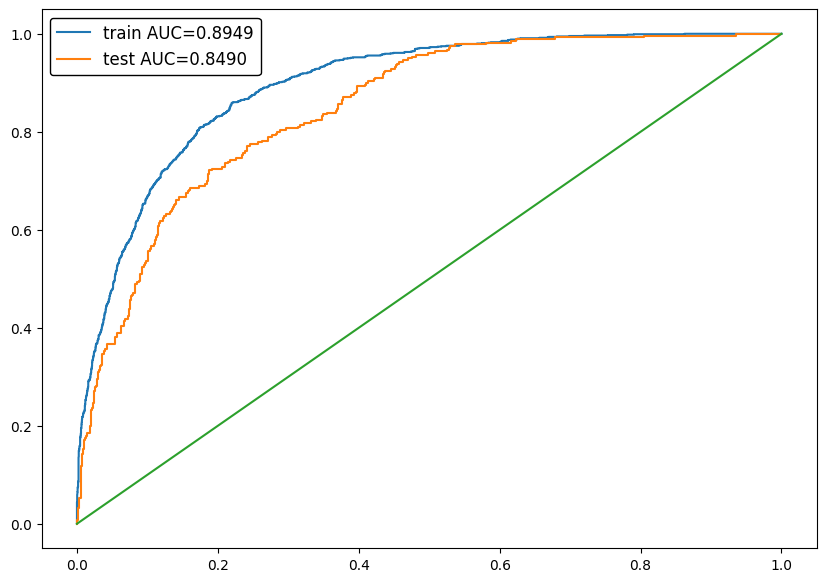

In [13]:
train_auc = roc_auc_score(y_train, y_train_predicted)
test_auc = roc_auc_score(y_test, y_test_predicted)

plt.figure(figsize=(10,7))
plt.plot(*roc_curve(y_train, y_train_predicted)[:2], label='train AUC={:.4f}'.format(train_auc))
plt.plot(*roc_curve(y_test, y_test_predicted)[:2], label='test AUC={:.4f}'.format(test_auc))
legend_box = plt.legend(fontsize='large', framealpha=1).get_frame()
legend_box.set_facecolor("white")
legend_box.set_edgecolor("black")
plt.plot(np.linspace(0,1,100), np.linspace(0,1,100))
plt.show()

Лучший результат у модели CatBoost: 0.8585

##**Предсказания**

In [14]:
best_model = boosting_model

In [15]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

X_test['TotalSpent'] = X_test['TotalSpent'].replace(' ', 0)
X_test['TotalSpent'] = X_test['TotalSpent'].astype(float)

del_col = ['HasOnlineBackup', 'HasDeviceProtection', 'HasMovieSubscription']
cat_cols = [i for i in cat_cols if i not in del_col]
X_test = X_test.drop(del_col, axis=1)



In [21]:
submission['Churn'] = 1 - best_model.predict_proba(X_test)
submission.to_csv('./my_submission.csv', index=False)